In [177]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## PART A

In [178]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\DELL\Downloads\xnzhj3x8v4-1\448"
CLASSES = ["Cracks", "NonCracks"]

for class_name in CLASSES:
    folder = os.path.join(DATA_DIR, class_name)
    files = os.listdir(folder)
    print(f"{class_name}: {len(files)} files")
    print("   first 3:", files[:3])

Cracks: 200 files
   first 3: ['IMG_20180513_164959951_HDR resized_448.jpg', 'IMG_20180513_165129852_HDR resized_448.jpg', 'IMG_20180513_165150613_HDR resized_448.jpg']
NonCracks: 200 files
   first 3: ['IMG_20180705_130729936 resized_448.jpg', 'IMG_20180705_130731751 resized_448.jpg', 'IMG_20180705_130732496 resized_448.jpg']


In [179]:
for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")

C:\Users\DELL\Downloads\xnzhj3x8v4-1\448 -> 0 files
C:\Users\DELL\Downloads\xnzhj3x8v4-1\448\Cracks -> 200 files
C:\Users\DELL\Downloads\xnzhj3x8v4-1\448\NonCracks -> 200 files


Type: <class 'numpy.ndarray'>
Shape: (448, 448, 3)
Data type: uint8
Min pixel: 29  Max pixel: 255


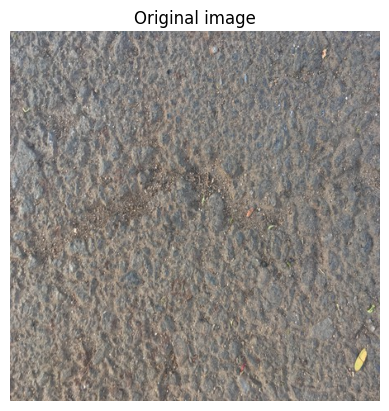

In [180]:
import cv2
path = r"C:\Users\DELL\Downloads\xnzhj3x8v4-1\448\Cracks\IMG_8405 resized_448.jpg"

img = cv2.imread(path)

print("Type:", type(img))
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Min pixel:", img.min(), " Max pixel:", img.max())

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original image")
plt.axis("off")
plt.show()

In [181]:
from collections import Counter
import cv2

shapes = []
for class_name in CLASSES:
    folder = os.path.join(DATA_DIR, class_name)
    for fname in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            print("Could not read:", fname)
            continue
        shapes.append(img.shape)

print(Counter(shapes))

Counter({(448, 448, 3): 400})


Original: (448, 448, 3)
Resized:  (256, 256, 3)
Gray:     (256, 256)


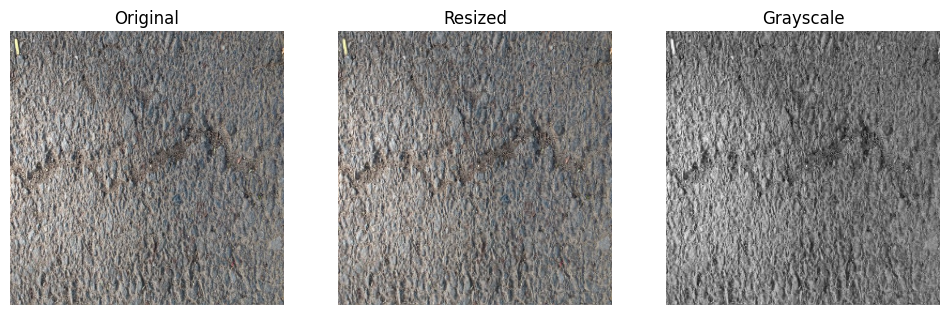

Original: (448, 448, 3)
Resized:  (128, 128, 3)
Gray:     (128, 128)


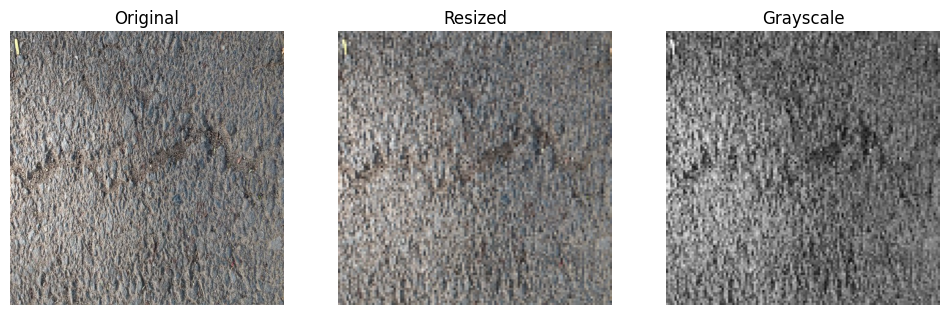

Original: (448, 448, 3)
Resized:  (64, 64, 3)
Gray:     (64, 64)


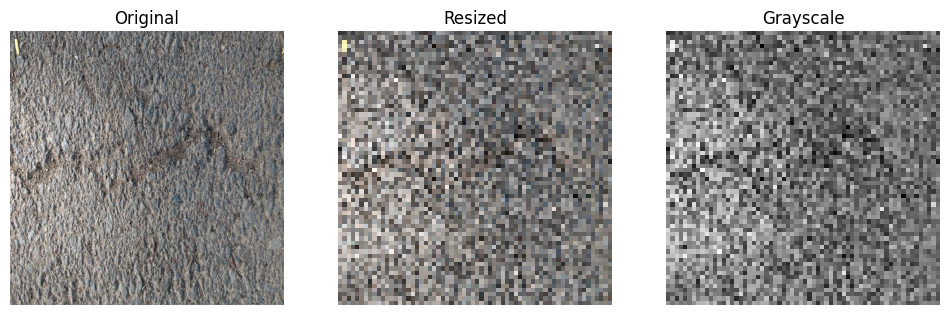

In [182]:
import matplotlib.pyplot as plt

LIST_IMG_SIZE = [(256, 256), (128, 128),  (64, 64)]   # (width, height)
for IMG_SIZE in LIST_IMG_SIZE:

    folder = os.path.join(DATA_DIR, "Cracks")
    fname = sorted(os.listdir(folder))[0]
    img = cv2.imread(os.path.join(folder, fname))

    resized = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    print("Original:", img.shape)
    print("Resized: ", resized.shape)
    print("Gray:    ", gray.shape)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original")
    axes[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)); axes[1].set_title("Resized")
    axes[2].imshow(gray, cmap="gray"); axes[2].set_title("Grayscale")
    for ax in axes:
        ax.axis("off")
    plt.show()

In [183]:
import numpy as np

DARK_THRESH = 60      # pixels below this count as "dark"
BRIGHT_THRESH = 180   # pixels above this count as "bright"

def intensity_features(gray):
    """Takes a 2D grayscale array, returns a dict of numeric features."""
    return {
        "mean_brightness": np.mean(gray),
        "contrast_std":    np.std(gray),
        "median":          np.median(gray),
        "min_pixel":       np.min(gray),
        "max_pixel":       np.max(gray),
        "p5":              np.percentile(gray, 5),
        "p95":             np.percentile(gray, 95),
        "dark_ratio":      np.mean(gray < DARK_THRESH),
        "bright_ratio":    np.mean(gray > BRIGHT_THRESH),
    }

features = intensity_features(gray)
for name, value in features.items():
    print(f"{name:18s} {value:.4f}")

mean_brightness    122.8567
contrast_std       38.3347
median             121.0000
min_pixel          10.0000
max_pixel          252.0000
p5                 64.0000
p95                190.0000
dark_ratio         0.0364
bright_ratio       0.0750


In [184]:
import pandas as pd

def load_gray(class_name, index=0):
    folder = os.path.join(DATA_DIR, class_name)
    fname = sorted(os.listdir(folder))[index]
    img = cv2.imread(os.path.join(folder, fname))
    img = cv2.resize(img, IMG_SIZE)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

crack_feats = intensity_features(load_gray("Cracks", 0))
non_feats   = intensity_features(load_gray("NonCracks", 0))

comparison = pd.DataFrame({"Crack": crack_feats, "NonCrack": non_feats})
print(comparison.round(4))

                    Crack  NonCrack
mean_brightness  122.8567  157.0808
contrast_std      38.3347   18.2689
median           121.0000  157.0000
min_pixel         10.0000   81.0000
max_pixel        252.0000  240.0000
p5                64.0000  128.0000
p95              190.0000  187.0000
dark_ratio         0.0364    0.0000
bright_ratio       0.0750    0.1003


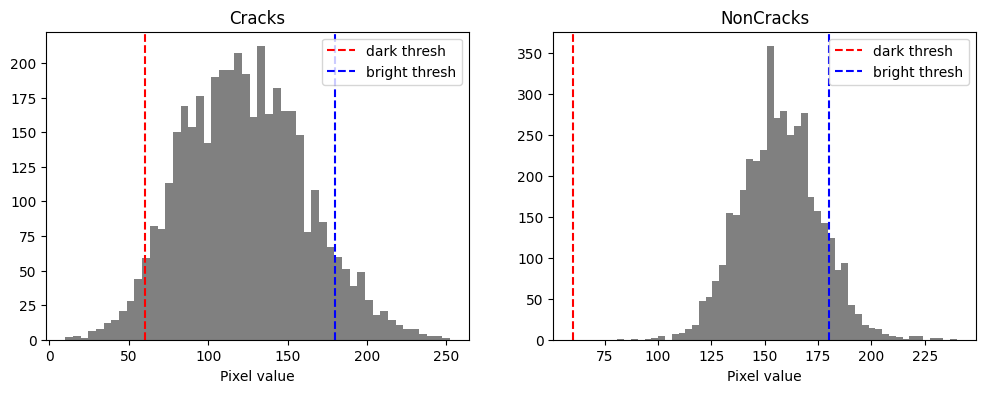

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cls in zip(axes, ["Cracks", "NonCracks"]):
    g = load_gray(cls, 0)
    ax.hist(g.ravel(), bins=50, color="gray")
    ax.axvline(DARK_THRESH, color="red", linestyle="--", label="dark thresh")
    ax.axvline(BRIGHT_THRESH, color="blue", linestyle="--", label="bright thresh")
    ax.set_title(cls)
    ax.set_xlabel("Pixel value")
    ax.legend()
plt.show()

In [186]:
import os
import cv2
import numpy as np
import pandas as pd

IMG_SIZE = (256, 256)
CLASSES = ["Cracks", "NonCracks"]

gray_images = []   # list of 2D arrays
labels = []        # 1 = crack, 0 = non-crack
filenames = []

for label, class_name in enumerate(["NonCracks", "Cracks"]):   # NonCracks=0, Cracks=1
    folder = os.path.join(DATA_DIR, class_name)
    for fname in sorted(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, fname))
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        gray_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
        labels.append(label)
        filenames.append(fname)

gray_images = np.array(gray_images)   # shape: (400, 256, 256)
labels = np.array(labels)

print("Array shape:", gray_images.shape)
print("Crack count:", labels.sum(), " NonCrack count:", (labels == 0).sum())

per_image = pd.DataFrame({
    "label":   labels,
    "mean":    gray_images.mean(axis=(1, 2)),
    "std":     gray_images.std(axis=(1, 2)),
    "min":     gray_images.min(axis=(1, 2)),
    "max":     gray_images.max(axis=(1, 2)),
    "p5":      np.percentile(gray_images, 5, axis=(1, 2)),
    "p95":     np.percentile(gray_images, 95, axis=(1, 2)),
})

summary = per_image.groupby("label").agg(["mean", "std", "min", "max"]).T
summary.columns = ["NonCrack", "Crack"]
print(summary.round(2))

Array shape: (400, 256, 256)
Crack count: 200  NonCrack count: 200
           NonCrack   Crack
mean mean    157.40  144.14
     std      10.65   20.75
     min     128.43  110.24
     max     180.76  189.58
std  mean     24.76   31.58
     std       7.69    7.98
     min      15.44   16.48
     max      42.08   57.21
min  mean     59.07   25.04
     std      26.17   24.76
     min       8.00    0.00
     max     106.00  107.00
max  mean    251.70  252.27
     std       3.34    3.26
     min     235.00  231.00
     max     255.00  255.00
p5   mean    117.46   91.83
     std      22.47   26.26
     min      65.00   37.00
     max     157.00  157.00
p95  mean    198.59  195.68
     std      10.23   22.69
     min     162.00  143.00
     max     229.00  239.00


In [187]:
for thresh in [60, 80, 100, 110, 120]:
    dark_ratio = (gray_images < thresh).mean(axis=(1, 2))
    crack_avg = dark_ratio[labels == 1].mean()
    non_avg   = dark_ratio[labels == 0].mean()
    print(f"thresh {thresh:3d}:  Crack = {crack_avg:.4f}   NonCrack = {non_avg:.4f}   "
          f"ratio = {crack_avg / max(non_avg, 1e-9):.1f}x")

thresh  60:  Crack = 0.0167   NonCrack = 0.0024   ratio = 7.0x
thresh  80:  Crack = 0.0461   NonCrack = 0.0116   ratio = 4.0x
thresh 100:  Crack = 0.1169   NonCrack = 0.0344   ratio = 3.4x
thresh 110:  Crack = 0.1793   NonCrack = 0.0548   ratio = 3.3x
thresh 120:  Crack = 0.2623   NonCrack = 0.0862   ratio = 3.0x


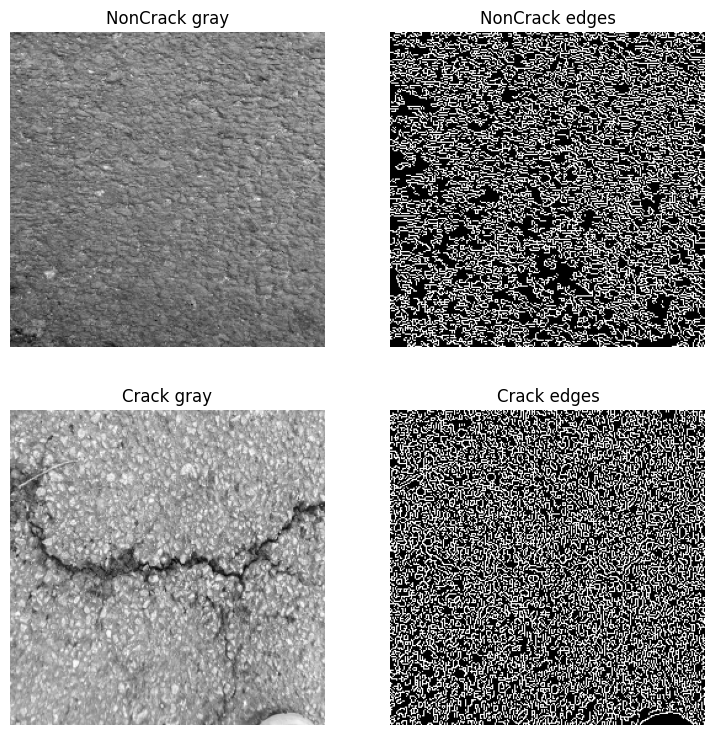

NonCrack edge density: 0.331451416015625
Crack edge density:    0.363616943359375


In [188]:
import matplotlib.pyplot as plt

g = gray_images[0]                 # a NonCrack (labels 0 come first)
c = gray_images[-1]                # a Crack

edges_g = cv2.Canny(g, 50, 150)
edges_c = cv2.Canny(c, 50, 150)

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
axes[0, 0].imshow(g, cmap="gray");        axes[0, 0].set_title("NonCrack gray")
axes[0, 1].imshow(edges_g, cmap="gray");  axes[0, 1].set_title("NonCrack edges")
axes[1, 0].imshow(c, cmap="gray");        axes[1, 0].set_title("Crack gray")
axes[1, 1].imshow(edges_c, cmap="gray");  axes[1, 1].set_title("Crack edges")
for ax in axes.ravel():
    ax.axis("off")
plt.show()

print("NonCrack edge density:", np.count_nonzero(edges_g) / edges_g.size)
print("Crack edge density:   ", np.count_nonzero(edges_c) / edges_c.size)

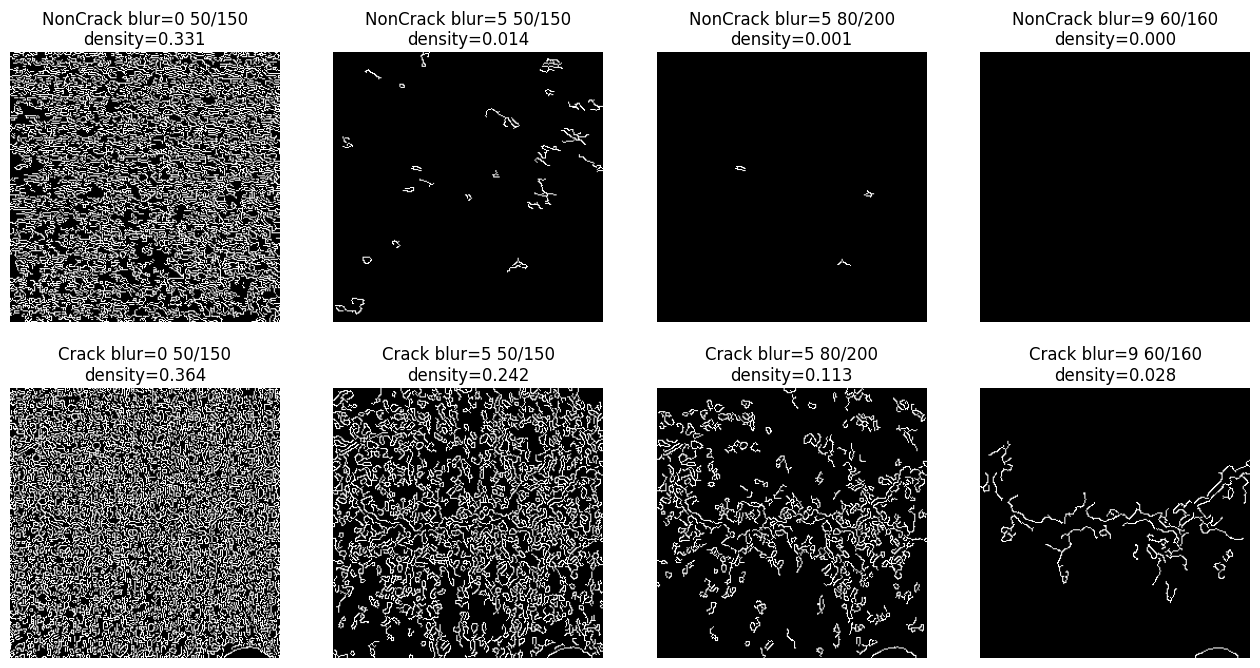

In [189]:
def show_canny(gray, blur_k, low, high):
    blurred = cv2.GaussianBlur(gray, (blur_k, blur_k), 0) if blur_k > 0 else gray
    return cv2.Canny(blurred, low, high)

settings = [(0, 50, 150), (5, 50, 150), (5, 80, 200), (9, 60, 160)]  # (blur, low, high)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (k, lo, hi) in enumerate(settings):
    for row, (img, name) in enumerate([(g, "NonCrack"), (c, "Crack")]):
        e = show_canny(img, k, lo, hi)
        axes[row, col].imshow(e, cmap="gray")
        axes[row, col].set_title(f"{name} blur={k} {lo}/{hi}\ndensity={np.count_nonzero(e)/e.size:.3f}")
        axes[row, col].axis("off")
plt.show()

In [190]:
import numpy as np

crack_idx = np.where(labels == 1)[0]
noncrack_idx = np.where(labels == 0)[0]

# 3 different crack images, 3 different non-crack images
sample_crack_idx = [crack_idx[0], crack_idx[50], crack_idx[150]]
sample_noncrack_idx = [noncrack_idx[0], noncrack_idx[50], noncrack_idx[150]]

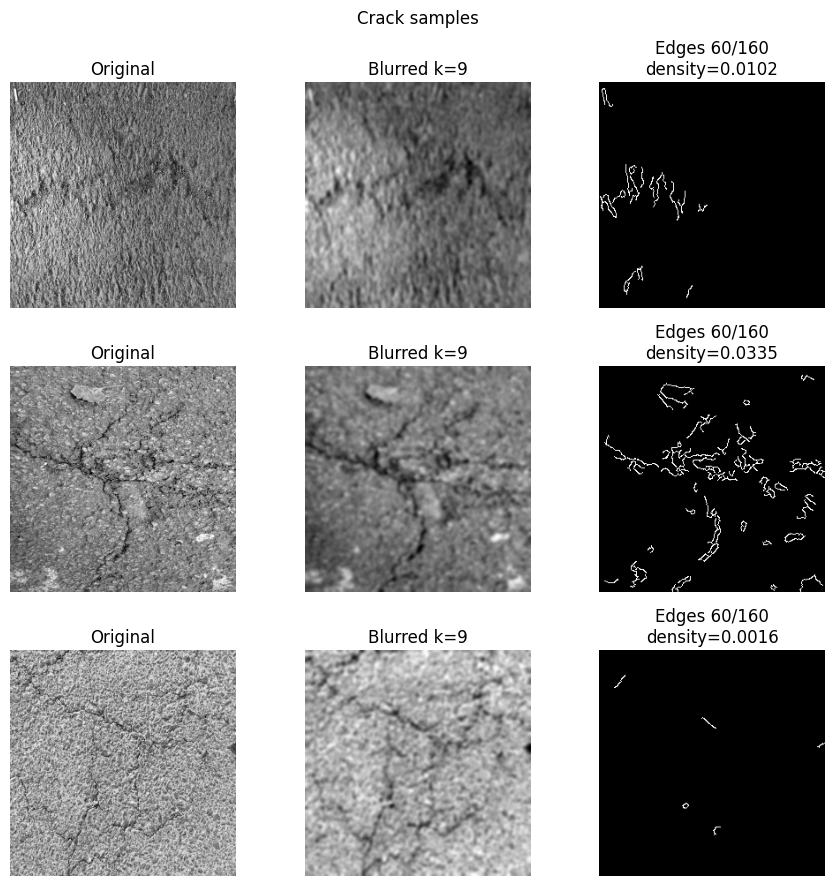

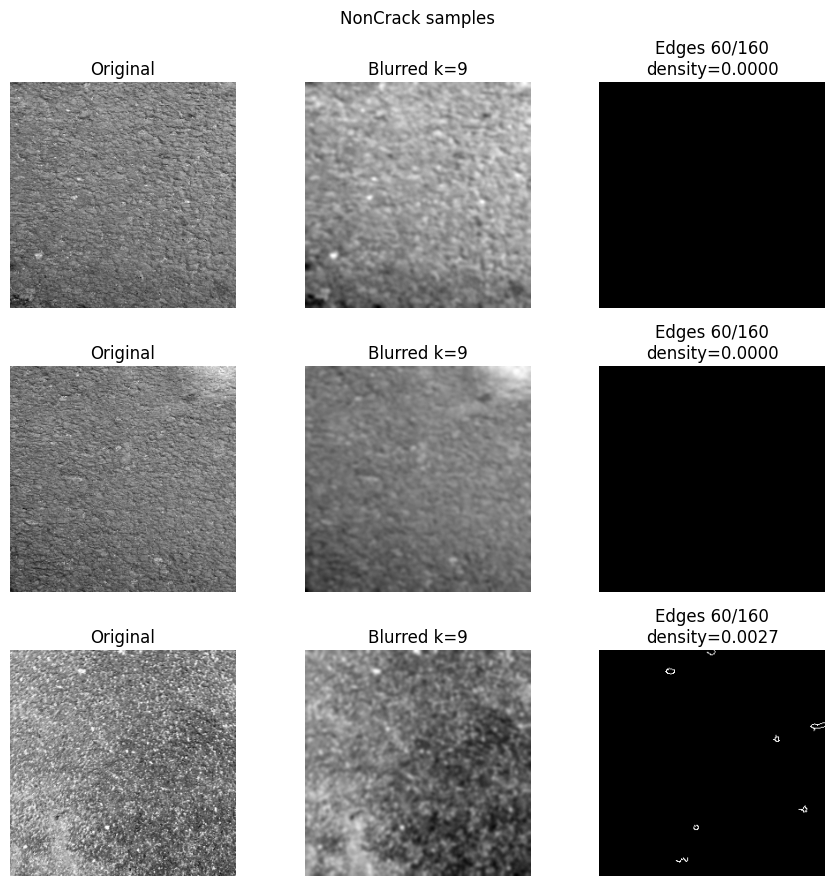

In [191]:
import cv2
import matplotlib.pyplot as plt

def show_pipeline(indices, blur_k, low, high, title):
    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 3 * len(indices)))
    for row, idx in enumerate(indices):
        g = gray_images[idx]
        blurred = cv2.GaussianBlur(g, (blur_k, blur_k), 0)
        edges = cv2.Canny(blurred, low, high)

        axes[row, 0].imshow(g, cmap="gray");        axes[row, 0].set_title("Original")
        axes[row, 1].imshow(blurred, cmap="gray");  axes[row, 1].set_title(f"Blurred k={blur_k}")
        axes[row, 2].imshow(edges, cmap="gray")
        axes[row, 2].set_title(f"Edges {low}/{high}\ndensity={np.count_nonzero(edges)/edges.size:.4f}")
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pipeline(sample_crack_idx, blur_k=9, low=60, high=160, title="Crack samples")
show_pipeline(sample_noncrack_idx, blur_k=9, low=60, high=160, title="NonCrack samples")

In [192]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(labels))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,        # 20% held out for testing
    random_state=42,      # reproducibility
    stratify=labels        # keep the 50/50 class balance in both splits
)

print("Train size:", len(train_idx), " Test size:", len(test_idx))
print("Train class balance:", np.bincount(labels[train_idx]))
print("Test class balance:", np.bincount(labels[test_idx]))

Train size: 320  Test size: 80
Train class balance: [160 160]
Test class balance: [40 40]


In [193]:
import cv2
import numpy as np
import pandas as pd

def compute_density(gray, blur_k, low, high):
    blurred = cv2.GaussianBlur(gray, (blur_k, blur_k), 0) if blur_k > 0 else gray
    edges = cv2.Canny(blurred, low, high)
    return np.count_nonzero(edges) / edges.size

train_gray = gray_images[train_idx]
train_labels = labels[train_idx]

settings_to_try = [
    (5, 80, 200),
    (7, 70, 180),
    (7, 80, 200),
    (9, 60, 160),
    (9, 70, 180),
]

rows = []
for blur_k, low, high in settings_to_try:
    densities = np.array([compute_density(g, blur_k, low, high) for g in train_gray])
    crack_d = densities[train_labels == 1]
    non_d   = densities[train_labels == 0]
    rows.append({
        "blur": blur_k, "low": low, "high": high,
        "crack_mean": crack_d.mean(), "crack_min": crack_d.min(), "crack_std": crack_d.std(),
        "non_mean": non_d.mean(), "non_max": non_d.max(), "non_std": non_d.std(),
        "gap": crack_d.mean() - non_d.mean(),
    })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

 blur  low  high  crack_mean  crack_min  crack_std  non_mean  non_max  non_std    gap
    5   80   200      0.1214     0.0002     0.0861    0.0410   0.2957   0.0655 0.0803
    7   70   180      0.0537     0.0000     0.0567    0.0060   0.1247   0.0149 0.0477
    7   80   200      0.0375     0.0000     0.0465    0.0026   0.0677   0.0074 0.0349
    9   60   160      0.0328     0.0000     0.0398    0.0016   0.0499   0.0051 0.0311
    9   70   180      0.0210     0.0000     0.0296    0.0005   0.0190   0.0019 0.0205


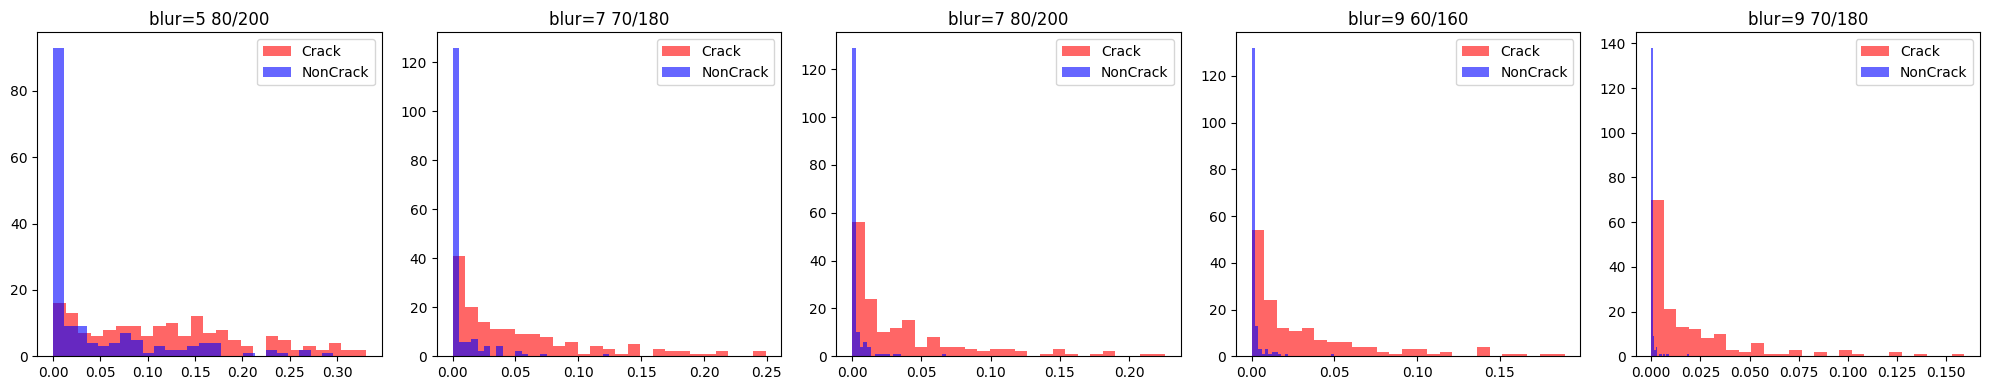

In [194]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(settings_to_try), figsize=(4 * len(settings_to_try), 4))
for ax, (blur_k, low, high) in zip(axes, settings_to_try):
    densities = np.array([compute_density(g, blur_k, low, high) for g in train_gray])
    ax.hist(densities[train_labels == 1], bins=25, alpha=0.6, label="Crack", color="red")
    ax.hist(densities[train_labels == 0], bins=25, alpha=0.6, label="NonCrack", color="blue")
    ax.set_title(f"blur={blur_k} {low}/{high}")
    ax.legend()
plt.tight_layout()
plt.show()

Crack image index:    316
NonCrack image index: 77


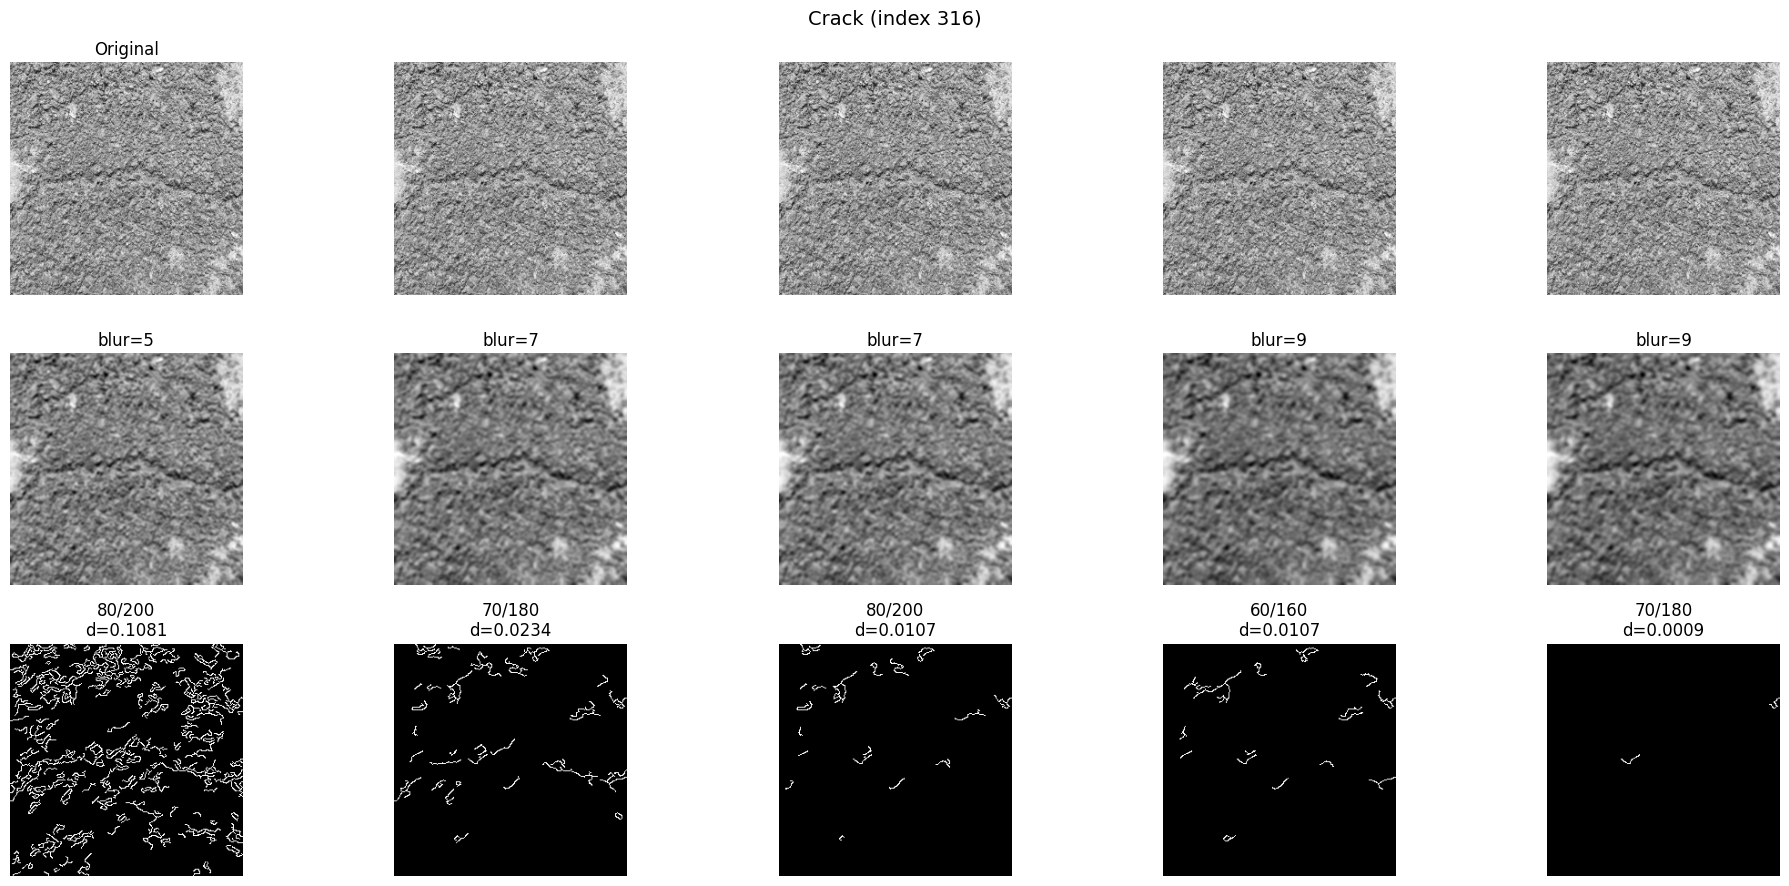

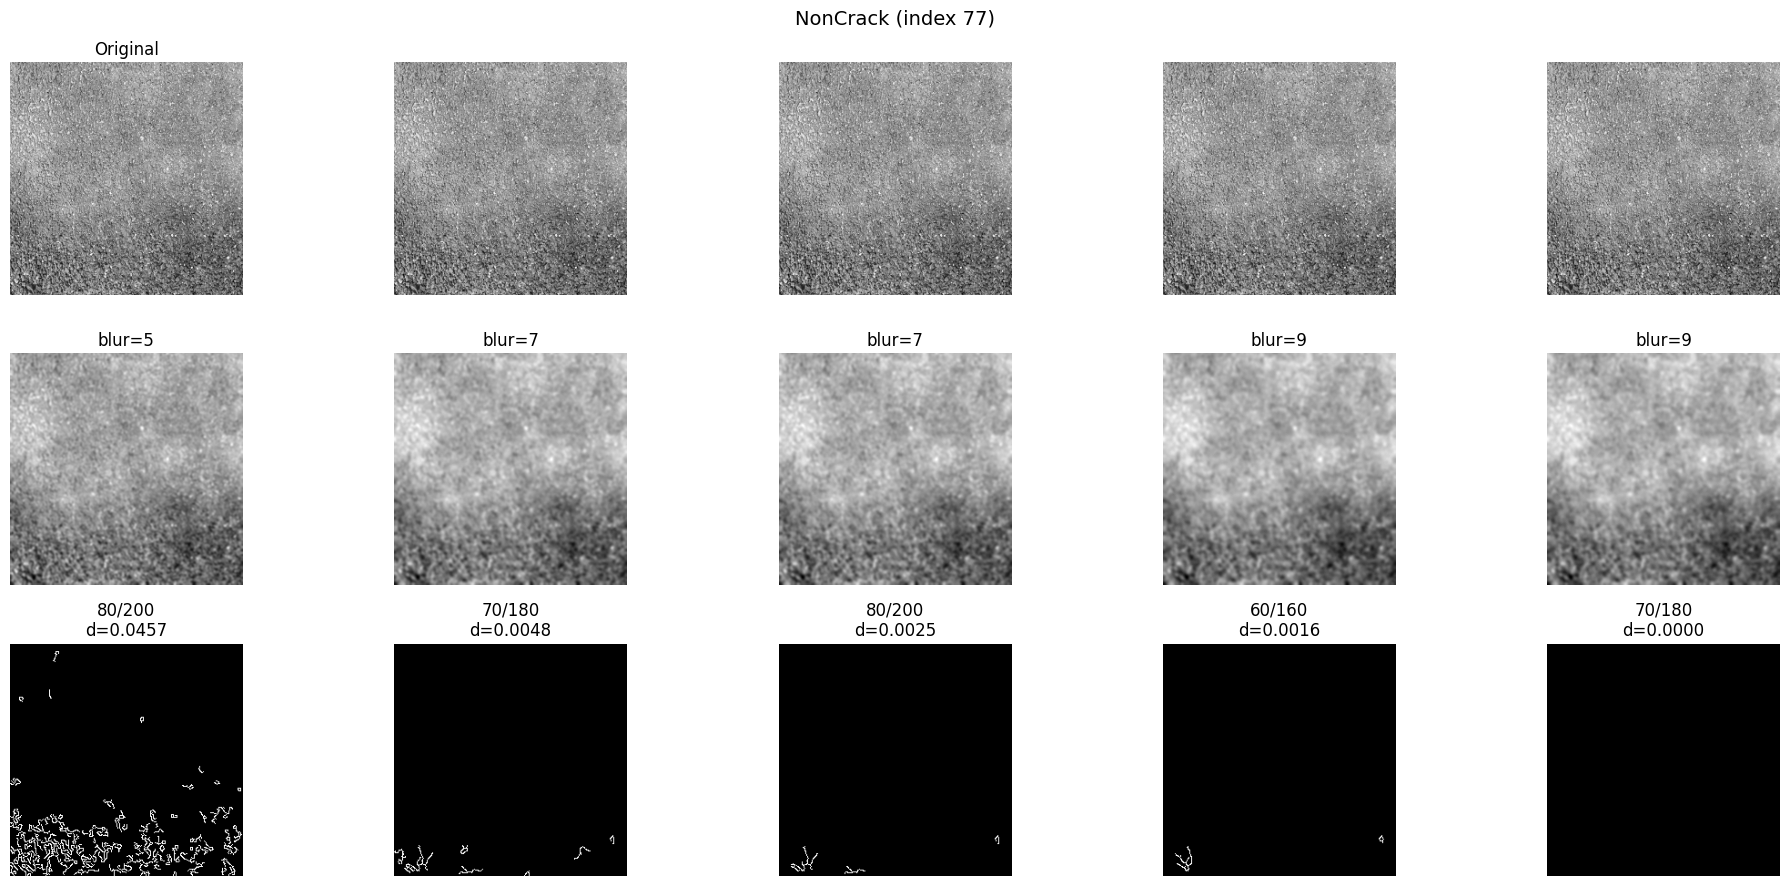

In [195]:
import numpy as np

# get indices that are in the training set AND belong to each class
train_crack_idx = train_idx[labels[train_idx] == 1]
train_noncrack_idx = train_idx[labels[train_idx] == 0]

# pick one of each (you can change the index if you want a different example)
sample_crack = train_crack_idx[2]
sample_noncrack = train_noncrack_idx[2]

print("Crack image index:   ", sample_crack)
print("NonCrack image index:", sample_noncrack)

import cv2
import matplotlib.pyplot as plt

settings_to_try = [
    (5, 80, 200),
    (7, 70, 180),
    (7, 80, 200),
    (9, 60, 160),
    (9, 70, 180),
]

def show_all_settings(idx, class_name):
    g = gray_images[idx]
    fig, axes = plt.subplots(3, len(settings_to_try), figsize=(4 * len(settings_to_try), 9))

    for col, (blur_k, low, high) in enumerate(settings_to_try):
        blurred = cv2.GaussianBlur(g, (blur_k, blur_k), 0)
        edges = cv2.Canny(blurred, low, high)
        density = np.count_nonzero(edges) / edges.size

        axes[0, col].imshow(g, cmap="gray")
        axes[0, col].set_title("Original" if col == 0 else "")
        axes[1, col].imshow(blurred, cmap="gray")
        axes[1, col].set_title(f"blur={blur_k}")
        axes[2, col].imshow(edges, cmap="gray")
        axes[2, col].set_title(f"{low}/{high}\nd={density:.4f}")

        for row in range(3):
            axes[row, col].axis("off")

    fig.suptitle(f"{class_name} (index {idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

show_all_settings(sample_crack, "Crack")
show_all_settings(sample_noncrack, "NonCrack")

In [196]:
import time

DARK_THRESH, BRIGHT_THRESH = 80, 180
BLUR_KERNEL, CANNY_LOW, CANNY_HIGH = (7, 7), 70, 180

def extract_features(gray):
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
    return {
        "mean_brightness": gray.mean(), "contrast_std": gray.std(),
        "median": np.median(gray), "min_pixel": gray.min(), "max_pixel": gray.max(),
        "p5": np.percentile(gray, 5), "p95": np.percentile(gray, 95),
        "dark_ratio": np.mean(gray < DARK_THRESH), "bright_ratio": np.mean(gray > BRIGHT_THRESH),
        "edge_count": np.count_nonzero(edges), "edge_density": np.count_nonzero(edges) / edges.size,
    }

rows = [extract_features(g) for g in gray_images]
feature_df = pd.DataFrame(rows)
feature_df["label"] = labels

feature_df.to_csv(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\image_features.csv", index=False)
feature_df.head()

,mean_brightness,contrast_std,median,min_pixel,max_pixel,p5,p95,dark_ratio,bright_ratio,edge_count,edge_density,label
0,157.136887,16.379736,157.0,78,245,131.0,183.0,0.000015,0.073486,0,0.0,0
1,157.600739,17.332723,157.0,89,248,131.0,186.0,0.000000,0.085907,0,0.0,0
2,159.660309,15.863745,160.0,87,247,134.0,185.0,0.000000,0.091751,0,0.0,0
3,159.900787,15.487570,160.0,94,250,135.0,185.0,0.000000,0.088318,0,0.0,0
4,166.009445,20.078960,164.0,101,254,137.0,204.0,0.000000,0.192642,0,0.0,0


In [197]:
from sklearn.model_selection import train_test_split

X = feature_df.drop(columns="label")
y = feature_df["label"]

X_train, X_test, y_train, y_test = X.loc[train_idx], X.loc[test_idx], y.loc[train_idx], y.loc[test_idx]

In [198]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
}

results = []
for name, model in models.items():
    t0 = time.perf_counter(); model.fit(X_train_s, y_train); train_time = time.perf_counter() - t0
    t0 = time.perf_counter(); y_pred = model.predict(X_test_s); predict_time = time.perf_counter() - t0

    results.append({
        "model": name, "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred), "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred), "train_time_s": train_time, "predict_time_s": predict_time,
    })
    print(f"\n{name}\nConfusion matrix:\n{confusion_matrix(y_test, y_pred)}")

results_df = pd.DataFrame(results)
results_df.to_csv(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\model_results.csv", index=False)
results_df


Logistic Regression
Confusion matrix:
[[38  2]
 [ 5 35]]

Random Forest
Confusion matrix:
[[38  2]
 [ 2 38]]

SVM
Confusion matrix:
[[38  2]
 [ 3 37]]


,model,accuracy,precision,recall,f1,train_time_s,predict_time_s
0,Logistic Regression,0.9125,0.945946,0.875,0.909091,0.002645,0.000145
1,Random Forest,0.9500,0.950000,0.950,0.950000,0.123769,0.009036
2,SVM,0.9375,0.948718,0.925,0.936709,0.008756,0.001246


In [199]:
importances = pd.Series(
    RandomForestClassifier(random_state=42).fit(X_train_s, y_train).feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(importances)

edge_density       0.224919
edge_count         0.181904
p95                0.121395
min_pixel          0.099844
mean_brightness    0.088189
bright_ratio       0.087140
median             0.082710
dark_ratio         0.043314
p5                 0.033921
contrast_std       0.028337
max_pixel          0.008328
dtype: float64


In [200]:
# ── Fixed pipeline settings (locked in from our experiments) ──
IMG_SIZE = (256, 256)
BLUR_KERNEL, CANNY_LOW, CANNY_HIGH = (7, 7), 70, 180
DARK_THRESH, BRIGHT_THRESH = 80, 180

FEATURE_COLUMNS = list(X.columns)   # exact training column order, frozen at train time

def extract_all_features(gray):
    blurred = cv2.GaussianBlur(gray, BLUR_KERNEL, 0)
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
    return {
        "mean_brightness": gray.mean(), "contrast_std": gray.std(),
        "median": np.median(gray), "min_pixel": gray.min(), "max_pixel": gray.max(),
        "p5": np.percentile(gray, 5), "p95": np.percentile(gray, 95),
        "dark_ratio": np.mean(gray < DARK_THRESH), "bright_ratio": np.mean(gray > BRIGHT_THRESH),
        "edge_count": np.count_nonzero(edges), "edge_density": np.count_nonzero(edges) / edges.size,
    }

def predict_crack(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    feats = extract_all_features(gray)
    feats_df = pd.DataFrame([feats])[FEATURE_COLUMNS]
    feats_scaled = image_scaler.transform(feats_df)

    pred = image_model.predict(feats_scaled)[0]
    proba = image_model.predict_proba(feats_scaled)[0][pred]
    return ("Crack" if pred == 1 else "NonCrack"), proba

In [201]:
image_model = models["Random Forest"]   # explicitly our chosen final model, not a loop leftover
image_scaler = scaler
FEATURE_COLUMNS = list(X.columns)

## PART B

In [202]:


import pandas as pd

df = pd.read_csv(r"C:\Users\DELL\Downloads\archive\emails.csv")
print(df.shape)
print(df.columns.tolist())
df.head()



(5172, 3002)
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'ne

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [203]:
print(df["Prediction"].value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [204]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(Xb_train.shape, Xb_test.shape)
print(yb_train.value_counts(normalize=True))
print(yb_test.value_counts(normalize=True))

(4137, 3000) (1035, 3000)
Prediction
0    0.709935
1    0.290065
Name: proportion, dtype: float64
Prediction
0    0.710145
1    0.289855
Name: proportion, dtype: float64


In [205]:
import time
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

text_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

text_results = []
for name, text_model in text_models.items():
    t0 = time.perf_counter(); text_model.fit(Xb_train, yb_train); train_time = time.perf_counter() - t0
    t0 = time.perf_counter(); y_pred = text_model.predict(Xb_test); predict_time = time.perf_counter() - t0

    text_results.append({
        "model": name, "accuracy": accuracy_score(yb_test, y_pred),
        "precision": precision_score(yb_test, y_pred), "recall": recall_score(yb_test, y_pred),
        "f1": f1_score(yb_test, y_pred), "train_time_s": train_time, "predict_time_s": predict_time,
    })
    print(f"\n{name}\nConfusion matrix:\n{confusion_matrix(yb_test, y_pred)}")

pd.DataFrame(text_results)


Naive Bayes
Confusion matrix:
[[692  43]
 [ 17 283]]

Logistic Regression
Confusion matrix:
[[722  13]
 [  5 295]]


,model,accuracy,precision,recall,f1,train_time_s,predict_time_s
0,Naive Bayes,0.942029,0.868098,0.943333,0.904153,0.053617,0.054634
1,Logistic Regression,0.982609,0.957792,0.983333,0.970395,3.503445,0.038361


In [206]:
pd.DataFrame(text_results).to_csv(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\text_model_results.csv", index=False)

## PART C

In [207]:
def extract_features_naive(gray):
    edges = cv2.Canny(gray, 50, 150)   # no blur, naive thresholds (our very first attempt)
    return {"edge_count": np.count_nonzero(edges), "edge_density": np.count_nonzero(edges) / edges.size}

naive_rows = [extract_features_naive(g) for g in gray_images]
naive_df = pd.DataFrame(naive_rows)
naive_df["label"] = labels

Xn_train = naive_df.drop(columns="label").loc[train_idx]
Xn_test  = naive_df.drop(columns="label").loc[test_idx]

t0 = time.perf_counter()
rf_naive = RandomForestClassifier(random_state=42).fit(Xn_train, y_train)
naive_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_pred_naive = rf_naive.predict(Xn_test)
naive_predict_time = time.perf_counter() - t0

comparison = pd.DataFrame([
    {"version": "Original (naive Canny, 2 features)", "n_features": 2,
     "accuracy": accuracy_score(y_test, y_pred_naive), "f1": f1_score(y_test, y_pred_naive),
     "train_time_s": naive_train_time, "predict_time_s": naive_predict_time},
    {"version": "Improved (tuned Canny + intensity, 11 features)", "n_features": 11,
     "accuracy": results_df.loc[results_df.model=="Random Forest", "accuracy"].values[0],
     "f1": results_df.loc[results_df.model=="Random Forest", "f1"].values[0],
     "train_time_s": results_df.loc[results_df.model=="Random Forest", "train_time_s"].values[0],
     "predict_time_s": results_df.loc[results_df.model=="Random Forest", "predict_time_s"].values[0]},
])
comparison.to_csv(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\part_c_comparison.csv", index=False)
comparison

,version,n_features,accuracy,f1,train_time_s,predict_time_s
0,"Original (naive Canny, 2 features)",2,0.6375,0.632911,0.123196,0.003036
1,"Improved (tuned Canny + intensity, 11 features)",11,0.9500,0.950000,0.123769,0.009036


In [208]:
# Part A (images) — rename once, right after building feature_df
y_img = feature_df["label"]
X_img = feature_df.drop(columns="label")

# Part B (text) — already have Xb_train/yb_train, but the full (unsplit) versions need names too
y_txt = df["Prediction"]
X_txt = df.drop(columns=["Email No.", "Prediction"])

In [209]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import time

def build_gray_at_size(size):
    imgs = []
    for label, class_name in enumerate(["NonCracks", "Cracks"]):
        folder = os.path.join(DATA_DIR, class_name)
        for fname in sorted(os.listdir(folder)):
            img = cv2.imread(os.path.join(folder, fname))
            img = cv2.resize(img, size)
            imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
    return np.array(imgs)

results_by_size = []
for size in [(128, 128), (256, 256), (448, 448)]:
    imgs_at_size = build_gray_at_size(size)

    t0 = time.perf_counter()
    feat_rows = [extract_features(g) for g in imgs_at_size]
    extract_time = time.perf_counter() - t0

    fdf = pd.DataFrame(feat_rows); fdf["label"] = labels
    Xs = fdf.drop(columns="label")
    Xs_train, Xs_test = Xs.loc[train_idx], Xs.loc[test_idx]

    sc = StandardScaler().fit(Xs_train)
    Xs_train_s, Xs_test_s = sc.transform(Xs_train), sc.transform(Xs_test)

    t0 = time.perf_counter()
    rf = RandomForestClassifier(random_state=42).fit(Xs_train_s, y_train)
    train_time = time.perf_counter() - t0

    y_pred = rf.predict(Xs_test_s)
    results_by_size.append({
        "size": f"{size[0]}x{size[1]}", "pixels": size[0]*size[1],
        "accuracy": accuracy_score(y_test, y_pred), "f1": f1_score(y_test, y_pred),
        "feature_extraction_time_s": extract_time, "train_time_s": train_time,
    })

pd.DataFrame(results_by_size)

,size,pixels,accuracy,f1,feature_extraction_time_s,train_time_s
0,128x128,16384,0.95,0.948718,0.348882,0.122734
1,256x256,65536,0.95,0.950000,0.988983,0.117648
2,448x448,200704,0.95,0.951220,2.950285,0.109822


### Multiscale Edge Feature (Part C Improvement)

Our original edge feature (`edge_density`) used a single blur/threshold setting (7×7 blur, Canny 70/180), tuned to detect thin cracks, but this meant thin and thick cracks could produce similar edge-density values, losing information about crack severity. We added a second edge-density feature computed under much heavier blurring (13×13, Canny 50/150), which only strong, wide edges survive; thin cracks are smoothed away at this scale while thick cracks remain, giving the model a second signal to distinguish crack thickness.

**Result:** validated with 5-fold cross-validation, mean F1 improved from **0.890 → 0.898**, with the largest single-fold gain on our weakest baseline fold (0.673 → 0.737), for a small added cost (~0.7s vs ~0.08s training time on 400 images).

In [210]:
def multiscale_edge_features(gray):
    feats = {}
    for k, low, high, tag in [(7, 70, 180, "fine"), (13, 50, 150, "coarse")]:
        blurred = cv2.GaussianBlur(gray, (k, k), 0)
        edges = cv2.Canny(blurred, low, high)
        feats[f"edge_density_{tag}"] = np.count_nonzero(edges) / edges.size
    return feats

In [211]:
def extract_features_multiscale(gray):
    return {**extract_features(gray), **multiscale_edge_features(gray)}

rows_ms = [extract_features_multiscale(g) for g in gray_images]
feature_df_ms = pd.DataFrame(rows_ms)
feature_df_ms["label"] = labels

X_ms = feature_df_ms.drop(columns="label")
X_ms_train, X_ms_test = X_ms.loc[train_idx], X_ms.loc[test_idx]

scaler_ms = StandardScaler().fit(X_ms_train)
X_ms_train_s, X_ms_test_s = scaler_ms.transform(X_ms_train), scaler_ms.transform(X_ms_test)

t0 = time.perf_counter()
rf_ms = RandomForestClassifier(random_state=42).fit(X_ms_train_s, y_train)
ms_train_time = time.perf_counter() - t0
y_pred_ms = rf_ms.predict(X_ms_test_s)

print("Single split:")
print("  Baseline (11 feat)   -> accuracy:", accuracy_score(y_test, image_model.predict(X_test_s)),
      " f1:", f1_score(y_test, image_model.predict(X_test_s)))
print("  Multiscale (13 feat) -> accuracy:", accuracy_score(y_test, y_pred_ms),
      " f1:", f1_score(y_test, y_pred_ms))
print("  Train time:", ms_train_time)

Single split:
  Baseline (11 feat)   -> accuracy: 0.95  f1: 0.95
  Multiscale (13 feat) -> accuracy: 0.9625  f1: 0.9629629629629629
  Train time: 0.10710209998069331


In [212]:
ms_cv = cross_val_score(RandomForestClassifier(random_state=42), X_ms, y_img, cv=5, scoring="f1")

print("\n5-fold CV:")
print("  Baseline (11 feat)   F1 per fold:", baseline_cv.round(3), " mean:", baseline_cv.mean().round(4))
print("  Multiscale (13 feat) F1 per fold:", ms_cv.round(3), " mean:", ms_cv.mean().round(4))


5-fold CV:
  Baseline (11 feat)   F1 per fold: [1.    0.952 0.673 0.918 0.907]  mean: 0.89
  Multiscale (13 feat) F1 per fold: [1.    0.952 0.737 0.907 0.892]  mean: 0.8976


In [213]:
image_model = rf_ms
image_scaler = scaler_ms
FEATURE_COLUMNS = list(X_ms.columns)

def coarse_edge_feature(gray):
    blurred = cv2.GaussianBlur(gray, (13, 13), 0)
    edges = cv2.Canny(blurred, 50, 150)
    return {"edge_density_coarse": np.count_nonzero(edges) / edges.size}

def extract_all_features(gray):
    return {**extract_features(gray), **coarse_edge_feature(gray)}

In [214]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

X_txt = df.drop(columns=["Email No.", "Prediction"])
y_txt = df["Prediction"]

baseline_txt_cv = cross_val_score(LogisticRegression(max_iter=1000), X_txt, y_txt, cv=5, scoring="f1")
print("Baseline (3000 word-count feat) F1 per fold:", baseline_txt_cv.round(3), " mean:", baseline_txt_cv.mean().round(4))

Baseline (3000 word-count feat) F1 per fold: [0.943 0.952 0.94  0.937 0.904]  mean: 0.9353


In [215]:
import time
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=UserWarning)  # suppress repeated convergence warnings in loop

# Rank words by frequency using TRAINING data only, to avoid leaking test-set info into feature selection
word_totals_train = X_txt.loc[Xb_train.index].sum(axis=0).sort_values(ascending=False)

vocab_results = []
for n in [3000, 1000, 500, 100]:
    top_words = word_totals_train.head(n).index
    X_sub_train = X_txt.loc[Xb_train.index, top_words]
    X_sub_test  = X_txt.loc[Xb_test.index, top_words]

    scaler_n = StandardScaler().fit(X_sub_train)
    X_sub_train_s = scaler_n.transform(X_sub_train)
    X_sub_test_s  = scaler_n.transform(X_sub_test)

    t0 = time.perf_counter()
    model = LogisticRegression(max_iter=2000).fit(X_sub_train_s, yb_train)
    train_time = time.perf_counter() - t0
    predict_t0 = time.perf_counter()
    y_pred = model.predict(X_sub_test_s)
    predict_time = time.perf_counter() - predict_t0

    vocab_results.append({
        "n_words": n, "f1": f1_score(yb_test, y_pred),
        "train_time_s": train_time, "predict_time_s": predict_time,
    })

vocab_df = pd.DataFrame(vocab_results)
print(vocab_df.round(4).to_string(index=False))

 n_words     f1  train_time_s  predict_time_s
    3000 0.9496        0.6018          0.0041
    1000 0.9427        0.2422          0.0023
     500 0.9462        0.1017          0.0010
     100 0.8195        0.0308          0.0003


### Regularization Tuning (Part C Improvement — Text)

We swept Logistic Regression's regularization strength (`C`) via cross-validation and found stronger regularization (`C=0.01`) improved mean F1 from 0.944 (default `C=1`) to 0.958, indicating the default was mildly overfitting the wide, sparse 3000-word feature space.

In [216]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

cv_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_txt_scaled = StandardScaler().fit_transform(X_txt)

# Try a range of C values on the full 3000-feature set
c_values = [0.001, 0.01, 0.1, 1, 10, 100]

c_results = []
for c in c_values:
    scores = cross_val_score(LogisticRegression(C=c, max_iter=2000), X_txt_scaled, y_txt, cv=cv_fixed, scoring="f1")
    c_results.append({"C": c, "mean_f1": scores.mean(), "std_f1": scores.std()})
    print(f"C={c:<8}  mean F1={scores.mean():.4f}  std={scores.std():.4f}")

# Pick the best C automatically, by highest mean F1
best = max(c_results, key=lambda r: r["mean_f1"])
best_C = best["C"]
print(f"\nBest C found: {best_C}  (mean F1 = {best['mean_f1']:.4f})")

# Update the final text model to use this best C
spam_model = LogisticRegression(C=best_C, max_iter=2000).fit(X_txt_scaled, y_txt)
print(f"\nFinal spam_model trained with C={best_C} on the full 3000-feature dataset.")

C=0.001     mean F1=0.8935  std=0.0071
C=0.01      mean F1=0.9576  std=0.0055
C=0.1       mean F1=0.9561  std=0.0074
C=1         mean F1=0.9439  std=0.0085
C=10        mean F1=0.9385  std=0.0074
C=100       mean F1=0.9428  std=0.0097

Best C found: 0.01  (mean F1 = 0.9576)

Final spam_model trained with C=0.01 on the full 3000-feature dataset.


In [217]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Final chosen text pipeline: full vocabulary, tuned regularization (best validated result)
text_scaler = StandardScaler().fit(X_txt)
X_txt_final_scaled = text_scaler.transform(X_txt)

spam_model = LogisticRegression(C=0.01, max_iter=2000).fit(X_txt_final_scaled, y_txt)
SPAM_FEATURE_COLUMNS = list(X_txt.columns)

print("Final spam_model trained: Logistic Regression, C=0.01, 3000 features")

Final spam_model trained: Logistic Regression, C=0.01, 3000 features


In [218]:
def predict_spam(word_counts: dict):
    """
    Takes a dict of {word: count} for one email (matching the training vocabulary),
    returns ('Spam'/'NotSpam', confidence).
    """
    row = pd.DataFrame([{col: word_counts.get(col, 0) for col in SPAM_FEATURE_COLUMNS}])
    row_scaled = text_scaler.transform(row)

    pred = spam_model.predict(row_scaled)[0]
    proba = spam_model.predict_proba(row_scaled)[0][pred]
    return ("Spam" if pred == 1 else "NotSpam"), proba

# quick test using an existing row from the dataset
sample_counts = df.loc[0, SPAM_FEATURE_COLUMNS].to_dict()
print(predict_spam(sample_counts))

('NotSpam', np.float64(0.7416775963803608))


In [219]:
text_vectorization_comparison = pd.DataFrame([
    {"representation": "Full word-count vectors (3000 words)", "n_features": 3000,
     "model": "Logistic Regression (C=1)", "mean_f1_cv": 0.9439},
    {"representation": "Top-500 words by frequency", "n_features": 500,
     "model": "Logistic Regression (C=1)", "mean_f1_cv": 0.9462},
    {"representation": "Full word-count vectors (3000 words)", "n_features": 3000,
     "model": "Logistic Regression (C=0.01, tuned)", "mean_f1_cv": 0.9576},
])
text_vectorization_comparison.to_csv(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\outputs\text_vectorization_comparison.csv", index=False)
print(text_vectorization_comparison)

                         representation  n_features  \
0  Full word-count vectors (3000 words)        3000   
1            Top-500 words by frequency         500   
2  Full word-count vectors (3000 words)        3000   

                                 model  mean_f1_cv  
0            Logistic Regression (C=1)      0.9439  
1            Logistic Regression (C=1)      0.9462  
2  Logistic Regression (C=0.01, tuned)      0.9576  


In [220]:
import os
os.makedirs(r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\outputs", exist_ok=True)
OUT = r"C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\outputs"

# 1. Sample raw images (one per class)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_images[crack_idx[0]], cmap="gray"); axes[0].set_title("Crack"); axes[0].axis("off")
axes[1].imshow(gray_images[noncrack_idx[0]], cmap="gray"); axes[1].set_title("NonCrack"); axes[1].axis("off")
plt.savefig(os.path.join(OUT, "sample_images.png"), bbox_inches="tight", dpi=150)
plt.close()

# 2. Canny edge visualization (final tuned settings) for both classes
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for row, idx in enumerate([crack_idx[0], noncrack_idx[0]]):
    g = gray_images[idx]
    blurred = cv2.GaussianBlur(g, BLUR_KERNEL, 0)
    edges = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
    axes[row, 0].imshow(g, cmap="gray"); axes[row, 0].set_title("Grayscale"); axes[row, 0].axis("off")
    axes[row, 1].imshow(edges, cmap="gray"); axes[row, 1].set_title("Canny edges"); axes[row, 1].axis("off")
plt.savefig(os.path.join(OUT, "canny_edge_visualization.png"), bbox_inches="tight", dpi=150)
plt.close()

print("Saved visualizations to:", OUT)

Saved visualizations to: C:\Users\DELL\OneDrive\Desktop\DAIICT\SEM1_DS605\outputs
